In [17]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

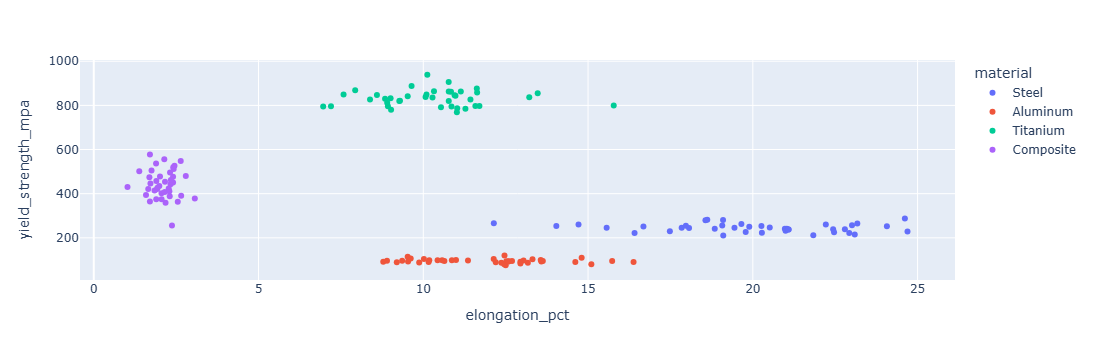

In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

materials = {
    "Steel":     {"n": 40, "yield_mpa": (250, 20), "elongation_pct": (20, 3)},
    "Aluminum":  {"n": 40, "yield_mpa": (95, 10),  "elongation_pct": (12, 2)},
    "Titanium":  {"n": 40, "yield_mpa": (830, 40), "elongation_pct": (10, 1.5)},
    "Composite": {"n": 40, "yield_mpa": (450, 60), "elongation_pct": (2, 0.5)},
}

rows = []
sample_id = 1
for mat, props in materials.items():
    n = props["n"]
    ys_mean, ys_std = props["yield_mpa"]
    el_mean, el_std = props["elongation_pct"]
    yield_vals = np.random.normal(ys_mean, ys_std, n)
    elong_vals = np.random.normal(el_mean, el_std, n)
    for y, e in zip(yield_vals, elong_vals):
        rows.append([f"S{sample_id:03d}", mat, y, e])
        sample_id += 1

df = pd.DataFrame(rows, columns=["sample_id", "material", "yield_strength_mpa", "elongation_pct"])

fig = px.scatter(df,  x = "elongation_pct", y = "yield_strength_mpa", color = "material", hover_data = ["sample_id"])
fig.show()

In [8]:
import numpy as np
import pandas as pd

np.random.seed(7)

records = []
spec_id = 1
stress_levels = ["Low", "Medium", "High"]
heat_treated_options = [True, False]

# lognormal params: (mean_log, sigma_log) roughly tuned so High stress = fewer cycles to failure
params = {
    ("Low", True):    (13.5, 0.3),
    ("Low", False):   (12.8, 0.4),
    ("Medium", True): (11.5, 0.35),
    ("Medium", False):(10.7, 0.45),
    ("High", True):   (9.0, 0.4),
    ("High", False):  (8.2, 0.5),
}

for stress in stress_levels:
    for ht in heat_treated_options:
        mu, sigma = params[(stress, ht)]
        n = 25
        cycles = np.random.lognormal(mean=mu, sigma=sigma, size=n)
        for c in cycles:
            records.append([f"F{spec_id:03d}", stress, ht, c])
            spec_id += 1

df = pd.DataFrame(records, columns=["specimen_id", "stress_level", "heat_treated", "cycles_to_failure"])
df.head()

,specimen_id,stress_level,heat_treated,cycles_to_failure
0,F001,Low,True,1.211243e+06
1,F002,Low,True,6.342629e+05
2,F003,Low,True,7.366337e+05
3,F004,Low,True,8.242712e+05
4,F005,Low,True,5.756891e+05


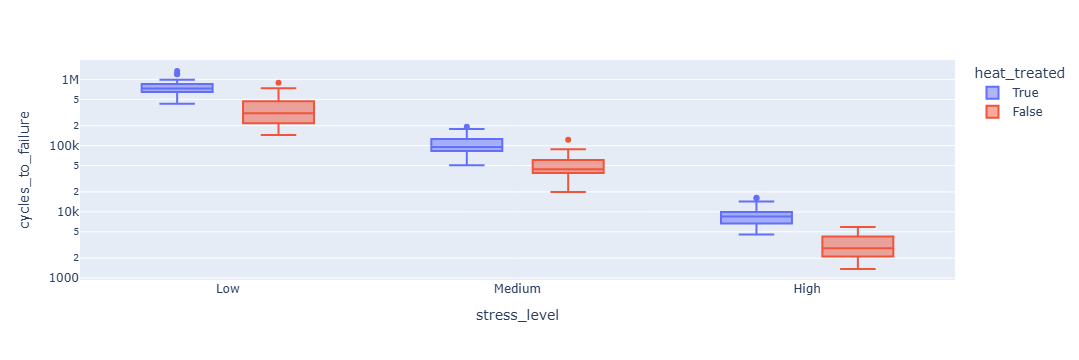

In [14]:
fig = px.box(df, x = "stress_level", y = "cycles_to_failure", color = "heat_treated")
fig.update_yaxes(type = "log")
fig.show()

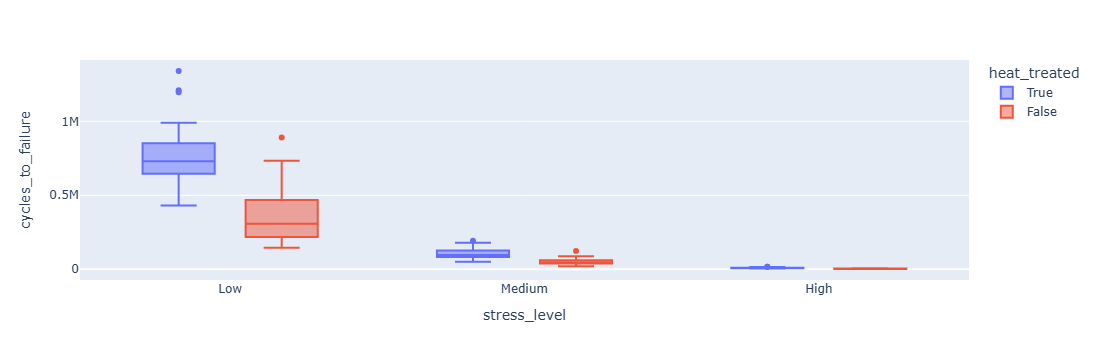

In [15]:
fig = px.box(df, x = "stress_level", y = "cycles_to_failure", color = "heat_treated")
fig.show()

In [23]:
np.random.seed(3)

n_points = 500
time_s = np.linspace(0, 50, n_points)

# Load oscillates (cyclic fatigue loading), with a slow upward drift (rig warming up / creep)
load_kn = 10 + 3 * np.sin(2 * np.pi * time_s / 2) + time_s * 0.05 + np.random.normal(0, 0.3, n_points)

# Deflection tracks load, but a small permanent set creeps in over time (plastic deformation)
deflection_mm = 0.5 * np.sin(2 * np.pi * time_s / 2 - 0.1) + time_s * 0.008 + np.random.normal(0, 0.02, n_points)

df = pd.DataFrame({"time_s": time_s, "load_kn": load_kn, "deflection_mm": deflection_mm})
df.head()

,time_s,load_kn,deflection_mm
0,0.000000,10.536589,-0.013611
1,0.100200,11.064810,0.091047
2,0.200401,11.805380,0.259907
3,0.300601,11.886359,0.368208
4,0.400802,12.792319,0.470164


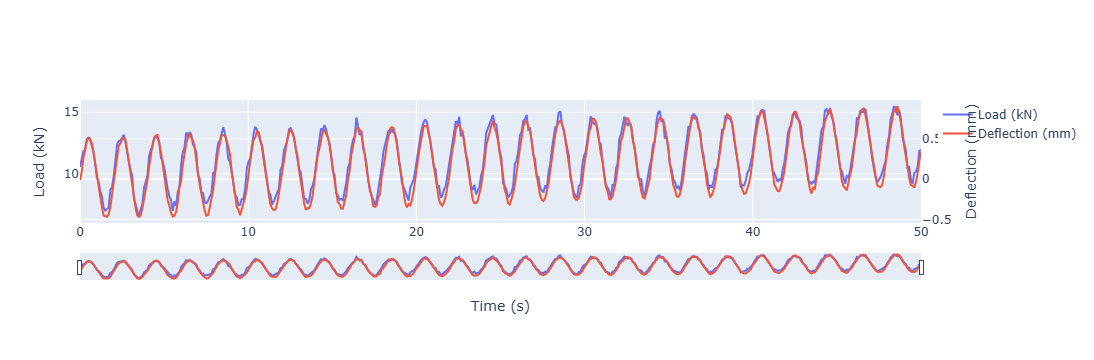

In [24]:
fig = go.Figure()

# Load trace
fig.add_trace(
    go.Scatter(
        x=df["time_s"],
        y=df["load_kn"],
        name="Load (kN)"
    )
)

# Deflection trace on secondary y-axis
fig.add_trace(
    go.Scatter(
        x=df["time_s"],
        y=df["deflection_mm"],
        name="Deflection (mm)",
        yaxis="y2"
    )
)

# Configure second y-axis and range slider
fig.update_layout(
    yaxis=dict(
        title="Load (kN)"
    ),
    yaxis2=dict(
        title="Deflection (mm)",
        overlaying="y",
        side="right"
    )
)

fig.update_xaxes(
    rangeslider=dict(
        visible=True
    ),
    title="Time (s)"
)

fig.show()

In [25]:
np.random.seed(11)

lines = ["Line_A", "Line_B", "Line_C"]
shifts = ["Day", "Night"]

records = []
for line in lines:
    for shift in shifts:
        n = 150
        # Night shift has slightly more variance (fatigue, lower staffing)
        base_mean = 45 if line != "Line_C" else 42  # Line_C miscalibrated, runs low
        std = 1.5 if shift == "Day" else 2.5
        torque = np.random.normal(base_mean, std, n)
        for t in torque:
            records.append([line, shift, t])

df = pd.DataFrame(records, columns=["production_line", "shift", "torque_nm"])
df.head()

,production_line,shift,torque_nm
0,Line_A,Day,47.624182
1,Line_A,Day,44.570891
2,Line_A,Day,44.273152
3,Line_A,Day,41.020022
4,Line_A,Day,44.987573


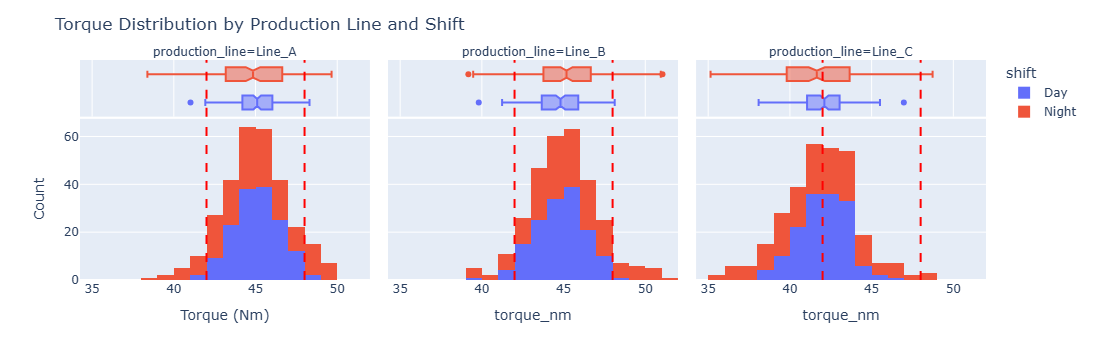

In [26]:
fig = px.histogram(
    df,
    x="torque_nm",
    color="shift",
    facet_col="production_line",
    marginal="box",
    nbins=30
)

fig.add_vline(x=42, line_dash="dash", line_color="red")
fig.add_vline(x=48, line_dash="dash", line_color="red")

fig.update_layout(
    title="Torque Distribution by Production Line and Shift",
    xaxis_title="Torque (Nm)",
    yaxis_title="Count"
)

fig.show()